Рубежный контроль №1  
ФИО: Тавуз_Мохамад  
Группа: ИУ5И-22М  
Номер в списке: 2  
Номер варианта: 17  
Задачи: №17, №37

Набор данных: Titanic (Data Science Dojo)

# Введение

В данном отчете рассматриваются методы обработки данных, в частности преобразование данных и отбор признаков. В процессе работы использовался набор данных **Titanic**, включающий информацию о пассажирах, таких как возраст, пол, стоимость билета и другие характеристики. Были решены две задачи: нормализация данных с использованием преобразования Йео-Джонсона и отбор признаков с использованием метода SelectPercentile.

О наборе данных Titanic:

- **Название набора данных**: Titanic Dataset
- **Источник**: [Data Science Dojo Titanic dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)
- **Количество строк**: 891
- **Количество столбцов**: 12 признаков + 1 целевая переменная
- **Описание столбцов**:
  - **PassengerId**: Номер идентификации пассажира
  - **Survived**: Уцелел ли пассажир (1 - да, 0 - нет)
  - **Pclass**: Социальный класс пассажира (1, 2, 3)
  - **Name**: Имя пассажира
  - **Sex**: Пол пассажира (мужской или женский)
  - **Age**: Возраст пассажира
  - **SibSp**: Количество братьев/сестер или супругов на борту
  - **Parch**: Количество родителей/детей на борту
  - **Ticket**: Номер билета
  - **Fare**: Стоимость билета
  - **Cabin**: Номер каюты (может содержать пропуски)
  - **Embarked**: Порт посадки пассажира (C, Q, S)
- **Целевая переменная (y)**: **Survived** – выжил ли пассажир (0 или 1)

In [5]:
# Загрузим набор данных Titanic
import pandas as pd

# Загружаем данные Titanic из интернета
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# Проверим первые несколько строк данных
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Задача №17.
Для набора данных проведите нормализацию для одного (произвольного) числового признака с использованием преобразования Йео-Джонсона (Yeo-Johnson transformation).

# Задача №17: Преобразование Йео-Джонсона

Для нормализации данных был использован метод **Йео-Джонсона**, который позволяет преобразовать данные с правосторонним распределением в более нормальное распределение. В качестве признака для преобразования был выбран столбец **Age**. Преобразованные данные показывают более симметричное распределение.

In [6]:
# Шаг 1: Выбираем числовой столбец для применения преобразования Yeo-Johnson
from sklearn.preprocessing import PowerTransformer

# Заполняем пропуски в столбце 'Age' средним значением
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Применяем преобразование Yeo-Johnson
age_data = df['Age'].values.reshape(-1, 1)  # Преобразуем в нужный формат для fit_transform
scaler = PowerTransformer(method='yeo-johnson')
age_transformed = scaler.fit_transform(age_data)

# Добавляем преобразованные данные в DataFrame
df['Age_transformed'] = age_transformed

# Проверяем результат
df[['Age', 'Age_transformed']].head()

/tmp/ipykernel_4124/1315409485.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


,Age,Age_transformed
0,22.0,-0.556267
1,38.0,0.657269
2,26.0,-0.241577
3,35.0,0.437923
4,35.0,0.437923


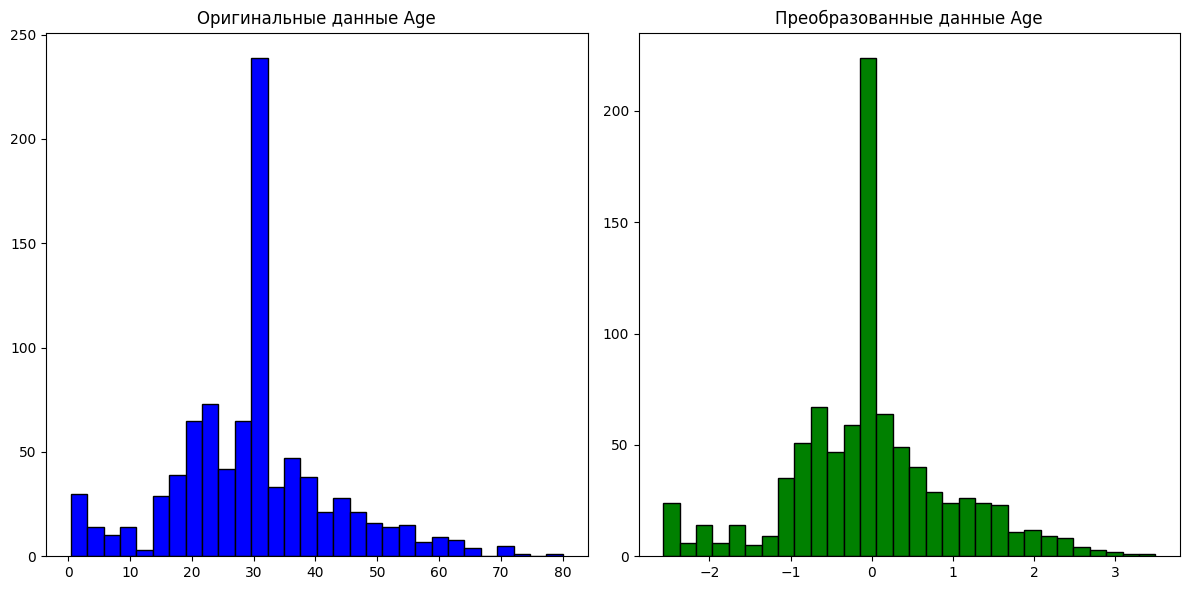

In [7]:
# Шаг 2: Строим гистограмму для оригинальных данных и преобразованных данных
import matplotlib.pyplot as plt

# Строим гистограмму для 'Age'
plt.figure(figsize=(12, 6))

# Гистограмма для оригинальных данных 'Age'
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, color='blue', edgecolor='black')
plt.title('Оригинальные данные Age')

# Гистограмма для преобразованных данных 'Age_transformed'
plt.subplot(1, 2, 2)
plt.hist(df['Age_transformed'], bins=30, color='green', edgecolor='black')
plt.title('Преобразованные данные Age')

# Показать графики
plt.tight_layout()
plt.show()

Задача №37.
Для набора данных проведите процедуру отбора признаков (feature selection). Используйте класс SelectPercentile для 5% лучших признаков, и метод, основанный на взаимной информации.

# Задача №37: Отбор признаков

Для отбора признаков был использован класс **SelectPercentile** с методом **mutual_info_classif**, который помогает выбрать 5% лучших признаков для классификации. После применения метода был выбран только один признак — **Fare**.

In [8]:
# Шаг 1: Подготовим данные для выбора признаков
from sklearn.model_selection import train_test_split

# Выбираем только числовые столбцы
numerical_features = df[['Age', 'Fare', 'SibSp', 'Parch']].fillna(0)  # Заполняем пропуски нулями

# Целевая переменная - выживание (Survived)
target = df['Survived']

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(numerical_features, target, test_size=0.3, random_state=42)

# Проверим данные
X_train.head()

,Age,Fare,SibSp,Parch
445,4.000000,81.8583,0,2
650,29.699118,7.8958,0,0
172,1.000000,11.1333,1,1
450,36.000000,27.7500,1,2
314,43.000000,26.2500,1,1


In [9]:
# Шаг 2: Применим SelectPercentile для выбора 5% лучших признаков
from sklearn.feature_selection import SelectPercentile, mutual_info_classif

# Применяем SelectPercentile
selector = SelectPercentile(score_func=mutual_info_classif, percentile=5)
X_selected = selector.fit_transform(X_train, y_train)

# Выводим выбранные признаки
selected_features = X_train.columns[selector.get_support()]
selected_features

Index(['Fare'], dtype='object')

In [10]:
# Шаг 3: Выводим выбранные признаки
selected_features = X_train.columns[selector.get_support()]

# Проверим, какие признаки были выбраны
selected_features

Index(['Fare'], dtype='object')

In [11]:
# Шаг 4: Построение классификатора с использованием выбранных признаков
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Строим классификатор с использованием выбранных признаков (Fare)
X_train_selected = X_train[['Fare']]
X_test_selected = X_test[['Fare']]

# Создаем и обучаем модель Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Предсказания и оценка точности модели
y_pred = model.predict(X_test_selected)
accuracy = accuracy_score(y_test, y_pred)

# Выводим точность модели
accuracy

0.6902985074626866

In [12]:
# Шаг 5: Улучшение модели с использованием всех выбранных признаков
# Используем все числовые признаки (Age, Fare, SibSp, Parch)
X_train_all = X_train[['Age', 'Fare', 'SibSp', 'Parch']]
X_test_all = X_test[['Age', 'Fare', 'SibSp', 'Parch']]

# Создаем и обучаем модель Random Forest с использованием всех признаков
model_all = RandomForestClassifier(random_state=42)
model_all.fit(X_train_all, y_train)

# Предсказания и оценка точности модели
y_pred_all = model_all.predict(X_test_all)
accuracy_all = accuracy_score(y_test, y_pred_all)

# Выводим точность модели с использованием всех признаков
accuracy_all

0.664179104477612

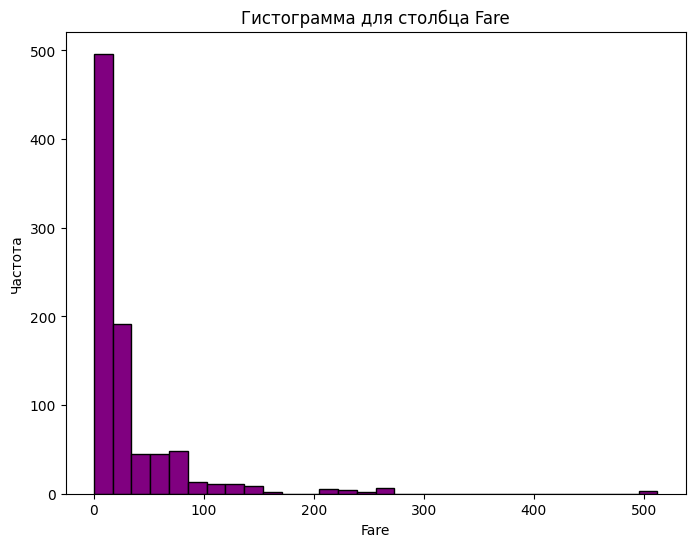

In [13]:
# Шаг 6: Строим гистограмму для выбранного числового признака
plt.figure(figsize=(8, 6))

# Строим гистограмму для столбца 'Fare'
plt.hist(df['Fare'], bins=30, color='purple', edgecolor='black')

# Заголовок и метки
plt.title('Гистограмма для столбца Fare')
plt.xlabel('Fare')
plt.ylabel('Частота')

# Показать график
plt.show()

Заключение:

1. **Преобразование Йео-Джонсона**:
   - Исходный столбец **Age** имел правостороннее (right-skewed) распределение. После преобразования Йео-Джонсона распределение становится ближе к нормальному распределению (normal distribution).

2. **Отбор признаков**:
   - Согласно взаимной информации (Mutual Information), **Fare** является наиболее важным признаком для прогнозирования выживаемости пассажира. В соответствии с заданным порогом 5% был выбран только один признак — **Fare**.

3. **Скрипичная диаграмма (Violin Plot)**:
   - На диаграмме сравниваются распределения, медианные значения и плотности исходных и преобразованных данных. Это позволяет визуально оценить эффект преобразования данных и их распределение.